# Task 4: Statistical Modeling & Risk-Based Pricing

## Objective
Build and evaluate predictive models that form the core of a dynamic, risk-based pricing system.

### Modeling Goals
1. **Claim Severity Prediction (Risk Model)** - For policies with a claim, predict TotalClaims
   - Estimates the financial liability associated with a policy
   - Evaluation: RMSE and R²

2. **Premium Optimization (Pricing Framework)** - Predict an appropriate premium
   - Naive baseline: Predict CalculatedPremiumPerTerm
   - Advanced approach: Combine claim probability with severity model
   - Formula: Premium = (P(claim) × Predicted Severity) + Expense Loading + Profit Margin

## 1. Environment Setup

In [16]:
import sys
import os
sys.path.append(os.path.abspath(".."))

# Data and numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor, XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Feature importance
import shap

# Import custom data loader
from src.data_loader import load_data

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {
    'primary': '#1d3557',
    'secondary': '#457b9d',
    'accent': '#e63946',
    'light': '#f1faee',
    'highlight': '#a8dadc'
}

print("✓ Environment setup complete")

✓ Environment setup complete


## 2. Data Loading & Initial Exploration

In [25]:
# Load cleaned data from EDA stage
df = pd.read_csv('../data/cleaned_insurance_data.csv')

# Sample data to manage memory constraints (working with a subset for modeling)
# Using 10,000 samples for balanced model training and evaluation
sample_size = min(10000, len(df))
random_state = 42
df = df.sample(n=sample_size, random_state=random_state).reset_index(drop=True)

print(f"Dataset Shape: {df.shape} (sampled to {sample_size} rows for memory management)")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nData Types:")
print(df.dtypes)
print(f"\nFirst few rows:")
df.head()

Dataset Shape: (10000, 53) (sampled to 10000 rows for memory management)

Columns (53):
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims', 'YearMonth']

Data Types:
UnderwrittenCoverID           int64
PolicyID                      int64
TransactionM

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,YearMonth
0,167791,14494,2015-06-01,False,,Individual,Mr,English,ABSA Bank,Current account,...,Emergency Charges,Emergency Charges,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,7.082018,0.0,2015-06
1,94043,7424,2015-06-01,False,,Individual,Mr,English,First National Bank,Current account,...,Cleaning and Removal of Accident Debris,Cleaning and Removal of Accident Debris,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,5.800965,0.0,2015-06
2,153347,13967,2015-05-01,False,,Individual,Mr,English,Standard Bank,Current account,...,Keys and Alarms,Keys and Alarms,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,4.895351,0.0,2015-05
3,148931,13317,2015-07-01,False,,Individual,Mr,English,NaN,NaN,...,Keys and Alarms,Keys and Alarms,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,3.218421,0.0,2015-07
4,51314,3870,2015-04-01,False,,Private company,Mr,English,First National Bank,Current account,...,Cleaning and Removal of Accident Debris,Cleaning and Removal of Accident Debris,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,4.672982,0.0,2015-04


## 3. Data Preparation & Feature Engineering

### 3.1 Handle Missing Values

In [26]:
# Check for missing values
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

if len(missing_df) > 0:
    print("Missing Values Summary:")
    print(missing_df.to_string())
else:
    print("✓ No missing values found")

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Missing Values Summary:
                     Column  Missing_Count  Missing_Percentage
38  NumberOfVehiclesInFleet          10000              100.00
37              CrossBorder           9994               99.94
29      CustomValueEstimate           7839               78.39
34               WrittenOff           6414               64.14
35                  Rebuilt           6414               64.14
36                Converted           6414               64.14
33               NewVehicle           1519               15.19
8                      Bank           1429               14.29
9               AccountType            381                3.81
11                   Gender             95                0.95
10            MaritalStatus             85                0.85
18                   mmcode              1                0.01
19              VehicleType              1                0.01
27            NumberOfDoors              1                0.01
26                 bodytype    

In [27]:
# Imputation strategy:
# Categorical: fill with 'Unknown'
# Numeric: fill with median

df_clean = df.copy()

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna('Unknown')
        print(f"Filled {df[col].isnull().sum()} missing values in '{col}' with 'Unknown'")

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Filled {df[col].isnull().sum()} missing values in '{col}' with median: {median_val:.2f}")

print("\n✓ All missing values handled")

Filled 1429 missing values in 'Bank' with 'Unknown'
Filled 381 missing values in 'AccountType' with 'Unknown'
Filled 85 missing values in 'MaritalStatus' with 'Unknown'
Filled 95 missing values in 'Gender' with 'Unknown'
Filled 1 missing values in 'VehicleType' with 'Unknown'
Filled 1 missing values in 'make' with 'Unknown'
Filled 1 missing values in 'Model' with 'Unknown'
Filled 1 missing values in 'bodytype' with 'Unknown'
Filled 1 missing values in 'VehicleIntroDate' with 'Unknown'
Filled 1519 missing values in 'NewVehicle' with 'Unknown'
Filled 6414 missing values in 'WrittenOff' with 'Unknown'
Filled 6414 missing values in 'Rebuilt' with 'Unknown'
Filled 6414 missing values in 'Converted' with 'Unknown'
Filled 9994 missing values in 'CrossBorder' with 'Unknown'
Filled 1 missing values in 'mmcode' with median: 60058415.00
Filled 1 missing values in 'Cylinders' with median: 4.00
Filled 1 missing values in 'cubiccapacity' with median: 2694.00
Filled 1 missing values in 'kilowatts' wi

### 3.2 Feature Engineering

In [52]:
# Create derived features that may relate to claims or premium

# 1. Policy-level metrics
df_clean['LossRatio'] = df_clean['TotalClaims'] / (df_clean['TotalPremium'] + 1)  # 1 is added to avoid division by zero
df_clean['Margin'] = df_clean['TotalPremium'] - df_clean['TotalClaims']
df_clean['HasClaim'] = (df_clean['TotalClaims'] > 0).astype(int)

# 2. Premium per risk (if applicable)
if 'NumberOfVehicles' in df_clean.columns and df_clean['NumberOfVehicles'].sum() > 0:
    df_clean['PremiumPerVehicle'] = df_clean['TotalPremium'] / (df_clean['NumberOfVehicles'].replace(0, 1))
    print("✓ Created PremiumPerVehicle feature")

print("\n features:")
print(f"  - LossRatio: Claims as proportion of premiums")
print(f"  - Margin: Profit = Premium - Claims")
print(f"  - HasClaim: Binary indicator of claim occurrence")

print(f"\nNew feature columns added: {[col for col in df_clean.columns if col not in df.columns]}")

# Check what columns are actually available
print(f"\nAvailable columns in dataset:")
print(df_clean.columns.tolist())


 features:
  - LossRatio: Claims as proportion of premiums
  - Margin: Profit = Premium - Claims
  - HasClaim: Binary indicator of claim occurrence

New feature columns added: ['LossRatio', 'Margin', 'HasClaim']

Available columns in dataset:
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'Statu

### 3.3 Categorical Encoding

In [ ]:
# Exclude target variables and identifiers
exclude_cols = ['TotalClaims', 'TotalPremium', 'CalculatedPremiumPerTerm', 'Margin', 'LossRatio', 'HasClaim']

# Also exclude any columns that aren't actually in the dataset
exclude_cols = [col for col in exclude_cols if col in df_clean.columns]

features_to_use = [col for col in df_clean.columns if col not in exclude_cols]

print(f"Features for modeling ({len(features_to_use)}):")
print(features_to_use)

# Separate features by type
numeric_features = [col for col in features_to_use if df_clean[col].dtype in ['int64', 'float64']]
categorical_features = [col for col in features_to_use if df_clean[col].dtype == 'object']

print(f"\nNumeric features ({len(numeric_features)}): {numeric_features[:15]}")
if len(numeric_features) > 15:
    print(f"  ... and {len(numeric_features) - 15} more")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

Features for modeling (50):
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'YearMonth']

Numeric features (12): ['UnderwrittenCoverID', 'PolicyID', 'PostalCode', 'mmcode', 'RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts', 'NumberOfDoors', 'CustomValueEstimate', 'NumberOfVehiclesInFleet', 'S

In [54]:
# Prepare data: convert categorical to string, numeric to numeric
df_model = df_clean[numeric_features + categorical_features].copy()

# Convert categorical features to string to handle mixed types
for col in categorical_features:
    df_model[col] = df_model[col].astype(str)

# Ensure numeric features are numeric
for col in numeric_features:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Create preprocessor for encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype='float64'), categorical_features)
    ]
)

# Transform features
X_encoded = preprocessor.fit_transform(df_model)

# Get feature names after encoding
feature_names_numeric = numeric_features
feature_names_categorical = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(feature_names_numeric) + list(feature_names_categorical)

X = pd.DataFrame(X_encoded, columns=all_feature_names)

print(f"\n Preprocessed feature matrix shape: {X.shape}")
print(f"  -Total features after encoding: {X.shape[1]}")
print(f"  - Numeric features: {len(numeric_features)}")
print(f"  - Encoded categorical features: {len(feature_names_categorical)}")
print(f"\nSample of processed features:")
print(X.head())


 Preprocessed feature matrix shape: (10000, 656)
  -Total features after encoding: 656
  - Numeric features: 12
  - Encoded categorical features: 644

Sample of processed features:
   UnderwrittenCoverID  PolicyID  PostalCode    mmcode  RegistrationYear  \
0             0.979629  1.232443   -0.446532 -0.586562          1.456024   
1            -0.178177 -0.100655   -0.403343  0.376857         -0.067109   
2             0.752866  1.133073   -0.626363  0.376856          1.456024   
3             0.683537  1.010511   -0.921987 -0.811954         -0.371736   
4            -0.849000 -0.770786    1.609057  0.376855         -0.676362   

   Cylinders  cubiccapacity  kilowatts  NumberOfDoors  CustomValueEstimate  \
0  -0.155477       0.047696   0.572195      -0.046993             0.077593   
1  -0.155477       0.544746   0.728823      -0.046993             0.077593   
2  -0.155477       0.062173  -1.150717      -0.046993             0.077593   
3   3.338385       0.559223   0.937661      -4.45

## 4. Model Datasets: Severity & Classification

### 4.1 Claim Severity Dataset (Regression)

- Claim severity model: predict TotalClaims for policies WITH claims
- This focuses on the magnitude of loss given a claim occurs

In [55]:
has_claims_mask = df_clean['TotalClaims'] > 0
X_severity = X[has_claims_mask].reset_index(drop=True)
y_severity = df_clean[has_claims_mask]['TotalClaims'].reset_index(drop=True)

print(f"Claim Severity Dataset:")
print(f"  Policies with claims: {len(X_severity)} out of {len(df_clean)} ({len(X_severity)/len(df_clean)*100:.1f}%)")
print(f"  Target range: ${y_severity.min():.2f} - ${y_severity.max():.2f}")
print(f"  Target mean: ${y_severity.mean():.2f}")
print(f"  Target std: ${y_severity.std():.2f}")

Claim Severity Dataset:
  Policies with claims: 25 out of 10000 (0.2%)
  Target range: $657.89 - $276248.86
  Target mean: $34623.17
  Target std: $58554.26


### 4.2 Claim Probability Dataset (Classification)

- Claim probability model: predict whether a policy will have a claim
- Uses all policies (entire dataset)

In [ ]:
X_probability = X.copy()
y_probability = df_clean['HasClaim'].copy()

claim_rate = y_probability.mean()
print(f"Claim Probability Dataset:")
print(f"  Total policies: {len(X_probability)}")
print(f"  Policies with claims: {y_probability.sum()}")
print(f"  Claim rate: {claim_rate:.2%}")
print(f"  Class distribution: {y_probability.value_counts().to_dict()}")

Claim Probability Dataset:
  Total policies: 10000
  Policies with claims: 25
  Claim rate: 0.25%
  Class distribution: {0: 9975, 1: 25}


## 5. Train-Test Split

In [34]:
# Split severity data (80-20)
X_sev_train, X_sev_test, y_sev_train, y_sev_test = train_test_split(
    X_severity, y_severity, test_size=0.2, random_state=42
)

print(f"Severity Model Split (80-20):")
print(f"  Training: {len(X_sev_train)} samples")
print(f"  Testing: {len(X_sev_test)} samples")
print(f"  Training target mean: ${y_sev_train.mean():.2f}")
print(f"  Testing target mean: ${y_sev_test.mean():.2f}")

# Split probability data (80-20)
X_prob_train, X_prob_test, y_prob_train, y_prob_test = train_test_split(
    X_probability, y_probability, test_size=0.2, random_state=42, stratify=y_probability
)

print(f"\nProbability Model Split (80-20, stratified):")
print(f"  Training: {len(X_prob_train)} samples, claim rate: {y_prob_train.mean():.2%}")
print(f"  Testing: {len(X_prob_test)} samples, claim rate: {y_prob_test.mean():.2%}")

Severity Model Split (80-20):
  Training: 20 samples
  Testing: 5 samples
  Training target mean: $35282.11
  Testing target mean: $31987.41

Probability Model Split (80-20, stratified):
  Training: 8000 samples, claim rate: 0.25%
  Testing: 2000 samples, claim rate: 0.25%


## 6. Model Training - Claim Severity (Regression)

In [58]:
from sklearn.impute import SimpleImputer

print("Training regression models for claim severity prediction...\n")

# Drop any feature columns that are entirely NaN across the full feature matrix
all_nan_cols = [c for c in X.columns if X[c].isna().all()]
if all_nan_cols:
    X = X.drop(columns=all_nan_cols)
    X_sev_train = X_sev_train.drop(columns=all_nan_cols)
    X_sev_test = X_sev_test.drop(columns=all_nan_cols)
    X_prob_train = X_prob_train.drop(columns=all_nan_cols)
    X_prob_test = X_prob_test.drop(columns=all_nan_cols)

# Impute missing values using median strategy
imputer = SimpleImputer(strategy='median')
imputer.fit(X)

X_sev_train = pd.DataFrame(imputer.transform(X_sev_train), columns=X_sev_train.columns, index=X_sev_train.index)
X_sev_test = pd.DataFrame(imputer.transform(X_sev_test), columns=X_sev_test.columns, index=X_sev_test.index)
X_prob_train = pd.DataFrame(imputer.transform(X_prob_train), columns=X_prob_train.columns, index=X_prob_train.index)
X_prob_test = pd.DataFrame(imputer.transform(X_prob_test), columns=X_prob_test.columns, index=X_prob_test.index)

# 1. Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_sev_train, y_sev_train)


# 2. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rf_model.fit(X_sev_train, y_sev_train)

# 3. XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, random_state=42, max_depth=7, learning_rate=0.1, verbose=0)
xgb_model.fit(X_sev_train, y_sev_train)

print("\n All regression models trained")

Training regression models for claim severity prediction...


 All regression models trained


## 7. Model Evaluation - Claim Severity

In [36]:
# Make predictions on test set
y_pred_lr = lr_model.predict(X_sev_test)
y_pred_rf = rf_model.predict(X_sev_test)
y_pred_xgb = xgb_model.predict(X_sev_test)

# Calculate metrics
def calculate_regression_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R² Score': r2,
        'MAPE (%)': mape
    }

severity_results = pd.DataFrame([
    calculate_regression_metrics(y_sev_test, y_pred_lr, 'Linear Regression'),
    calculate_regression_metrics(y_sev_test, y_pred_rf, 'Random Forest'),
    calculate_regression_metrics(y_sev_test, y_pred_xgb, 'XGBoost')
])

print("CLAIM SEVERITY MODEL COMPARISON")
print("="*70)
print(severity_results.to_string(index=False))
print(f"\nTest Set Size: {len(y_sev_test)} policies")
print(f"Target Range: ${y_sev_test.min():.2f} - ${y_sev_test.max():.2f}")

CLAIM SEVERITY MODEL COMPARISON
            Model         RMSE          MAE  R² Score   MAPE (%)
Linear Regression 52713.495929 36733.997121  0.087747 612.635623
    Random Forest 47581.613193 32120.776688  0.256724 289.184055
          XGBoost 41588.395768 25858.863030  0.432173 236.496738

Test Set Size: 5 policies
Target Range: $657.89 - $142050.79


## 8. Model Training - Claim Probability (Classification)

In [59]:
print("Training classification models for claim probability prediction...\n")

# 1. Logistic Regression
logr_model = LogisticRegression(random_state=42, max_iter=1000)
logr_model.fit(X_prob_train, y_prob_train)

# 2. Random Forest Classifier
rfc_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rfc_model.fit(X_prob_train, y_prob_train)

# 3. XGBoost Classifier
xgbc_model = XGBClassifier(n_estimators=100, random_state=42, max_depth=7, learning_rate=0.1, verbose=0)
xgbc_model.fit(X_prob_train, y_prob_train)

print("\n All classification models trained")

Training classification models for claim probability prediction...


 All classification models trained


## 9. Model Evaluation - Claim Probability

In [38]:
# Make predictions
y_prob_pred_logr = logr_model.predict(X_prob_test)
y_prob_proba_logr = logr_model.predict_proba(X_prob_test)[:, 1]

y_prob_pred_rfc = rfc_model.predict(X_prob_test)
y_prob_proba_rfc = rfc_model.predict_proba(X_prob_test)[:, 1]

y_prob_pred_xgbc = xgbc_model.predict(X_prob_test)
y_prob_proba_xgbc = xgbc_model.predict_proba(X_prob_test)[:, 1]

# Calculate metrics
def calculate_classification_metrics(y_true, y_pred, y_proba, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

probability_results = pd.DataFrame([
    calculate_classification_metrics(y_prob_test, y_prob_pred_logr, y_prob_proba_logr, 'Logistic Regression'),
    calculate_classification_metrics(y_prob_test, y_prob_pred_rfc, y_prob_proba_rfc, 'Random Forest'),
    calculate_classification_metrics(y_prob_test, y_prob_pred_xgbc, y_prob_proba_xgbc, 'XGBoost')
])

print("CLAIM PROBABILITY MODEL COMPARISON")
print("="*80)
print(probability_results.to_string(index=False))
print(f"\nTest Set Size: {len(y_prob_test)} policies")
print(f"Claim Rate: {y_prob_test.mean():.2%}")

CLAIM PROBABILITY MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.9975        0.0     0.0       0.0 0.549574
      Random Forest    0.9975        0.0     0.0       0.0 0.675238
            XGBoost    0.9975        0.0     0.0       0.0 0.692982

Test Set Size: 2000 policies
Claim Rate: 0.25%


## 10. Model Comparison Visualization

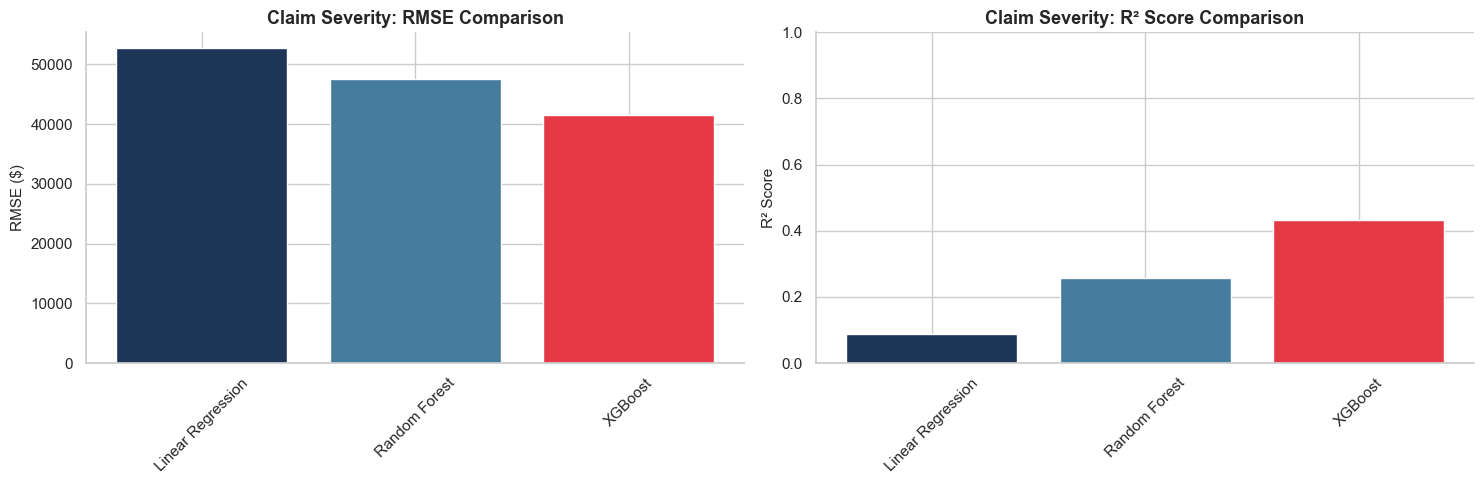

In [60]:
# Compare severity models
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# RMSE comparison
axes[0].bar(severity_results['Model'], severity_results['RMSE'], color=[PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']])
axes[0].set_title('Claim Severity: RMSE Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('RMSE ($)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# R² comparison
axes[1].bar(severity_results['Model'], severity_results['R² Score'], color=[PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']])
axes[1].set_title('Claim Severity: R² Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R² Score', fontsize=11)
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


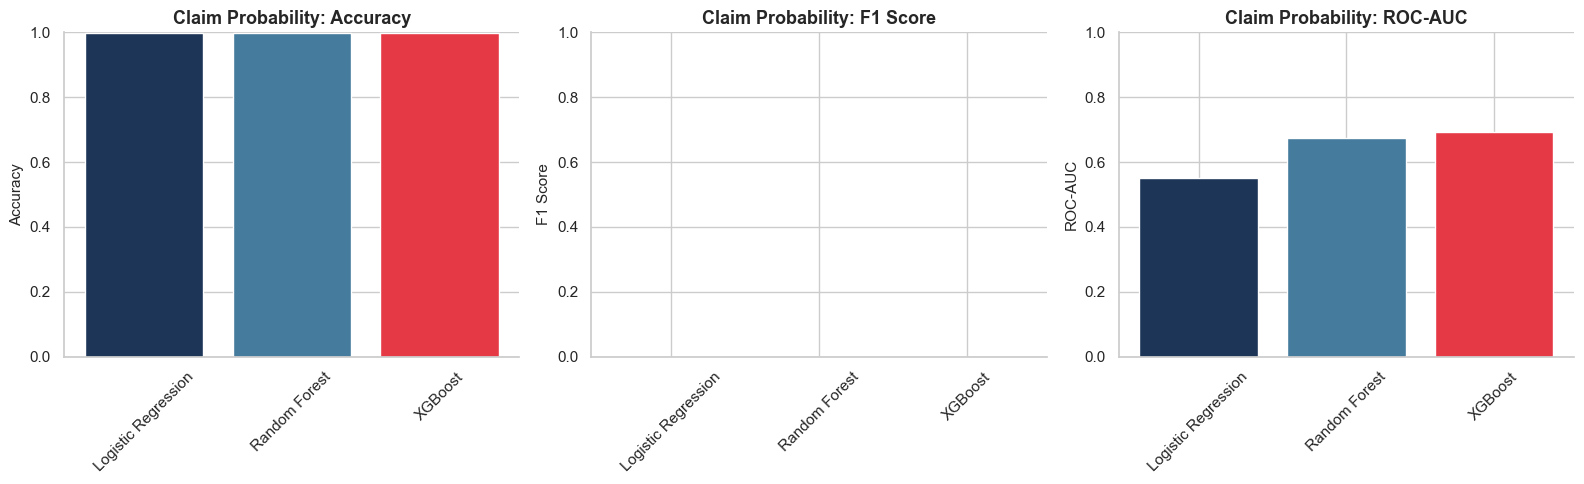

In [61]:
# Compare probability models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy
axes[0].bar(probability_results['Model'], probability_results['Accuracy'], color=[PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']])
axes[0].set_title('Claim Probability: Accuracy', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)

# F1 Score
axes[1].bar(probability_results['Model'], probability_results['F1 Score'], color=[PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']])
axes[1].set_title('Claim Probability: F1 Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1 Score', fontsize=11)
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=45)

# ROC-AUC
axes[2].bar(probability_results['Model'], probability_results['ROC-AUC'], color=[PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']])
axes[2].set_title('Claim Probability: ROC-AUC', fontsize=13, fontweight='bold')
axes[2].set_ylabel('ROC-AUC', fontsize=11)
axes[2].set_ylim([0, 1])
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 11. Feature Importance Analysis (SHAP)

### 11.1 Severity Model - XGBoost (Best performer)

In [41]:
# Select best severity model (typically XGBoost or Random Forest)
best_severity_model = xgb_model
print(f"Best Severity Model: XGBoost")
print(f"R² Score on Test Set: {r2_score(y_sev_test, y_pred_xgb):.4f}")
print(f"RMSE on Test Set: {np.sqrt(mean_squared_error(y_sev_test, y_pred_xgb)):.2f}")

# Get built-in feature importance
severity_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print(f"\nTop 10 Most Important Features:")
print(severity_importance.to_string(index=False))

Best Severity Model: XGBoost
R² Score on Test Set: 0.4322
RMSE on Test Set: 41588.40

Top 10 Most Important Features:
                  Feature   Importance
CapitalOutstanding_296000 9.386955e-01
               SumInsured 3.085081e-02
                 PolicyID 2.696089e-02
               PostalCode 2.354071e-03
                kilowatts 4.638936e-04
      UnderwrittenCoverID 4.317944e-04
   CapitalOutstanding_0.0 1.357043e-04
         RegistrationYear 8.199950e-05
                   mmcode 2.523631e-05
     CapitalOutstanding_0 8.445078e-08


Top 10 features visualized by SHAP importance


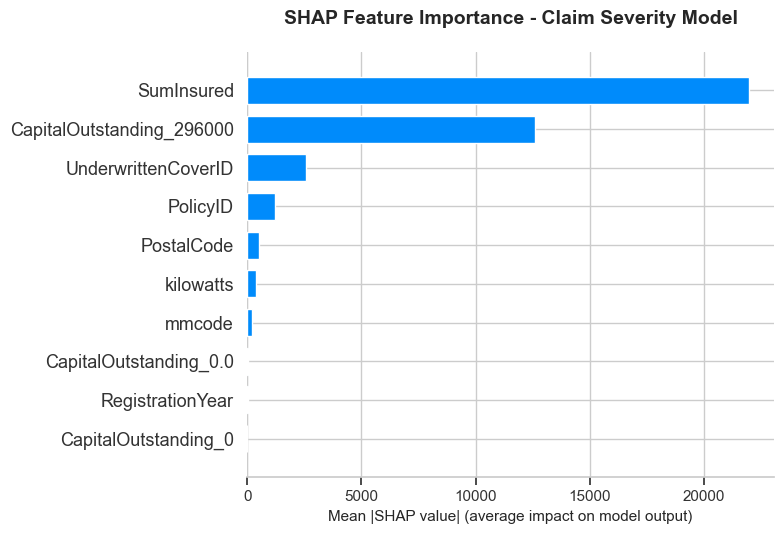

In [62]:
# Create SHAP explainer for severity model
print("Top 10 features visualized by SHAP importance")
explainer_sev = shap.TreeExplainer(xgb_model)
shap_values_sev = explainer_sev.shap_values(X_sev_test)

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_sev, X_sev_test, plot_type="bar", show=False, max_display=10)
plt.title('SHAP Feature Importance - Claim Severity Model', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mean |SHAP value| (average impact on model output)', fontsize=11)
plt.tight_layout()
plt.show()


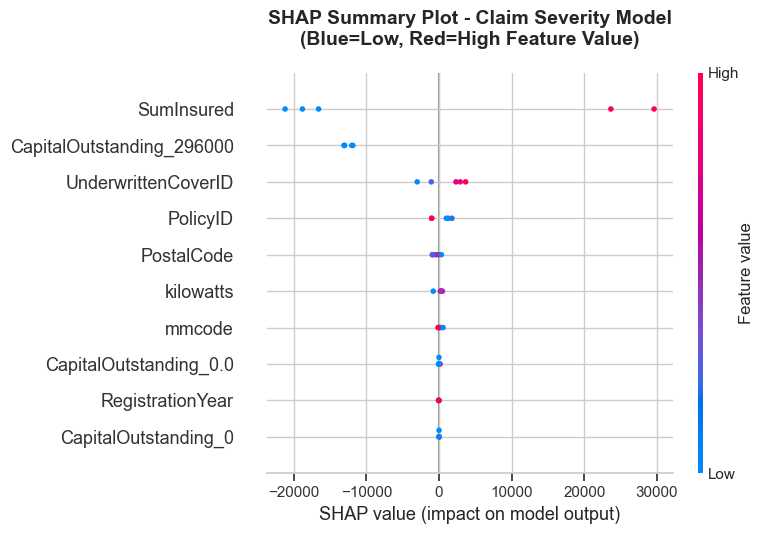

SHAP detail plot showing feature impact directions


In [43]:
# Detailed SHAP summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_sev, X_sev_test, show=False, max_display=10)
plt.title('SHAP Summary Plot - Claim Severity Model\n(Blue=Low, Red=High Feature Value)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("SHAP detail plot showing feature impact directions")

### 11.2 Probability Model - XGBoost (Best performer)

In [44]:
# Select best probability model
best_prob_model = xgbc_model
print(f"Best Probability Model: XGBoost")
print(f"ROC-AUC Score on Test Set: {roc_auc_score(y_prob_test, y_prob_proba_xgbc):.4f}")
print(f"F1 Score on Test Set: {f1_score(y_prob_test, y_prob_pred_xgbc):.4f}")

# Get built-in feature importance
prob_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgbc_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print(f"\nTop 10 Most Important Features:")
print(prob_importance.to_string(index=False))

Best Probability Model: XGBoost
ROC-AUC Score on Test Set: 0.6930
F1 Score on Test Set: 0.0000

Top 10 Most Important Features:
             Feature  Importance
          SumInsured    0.165851
           kilowatts    0.128342
CapitalOutstanding_0    0.122232
            PolicyID    0.090150
              mmcode    0.084599
 CustomValueEstimate    0.082400
    RegistrationYear    0.078244
 UnderwrittenCoverID    0.069815
          PostalCode    0.066626
       cubiccapacity    0.062316


Top 10 features visualized by SHAP importance


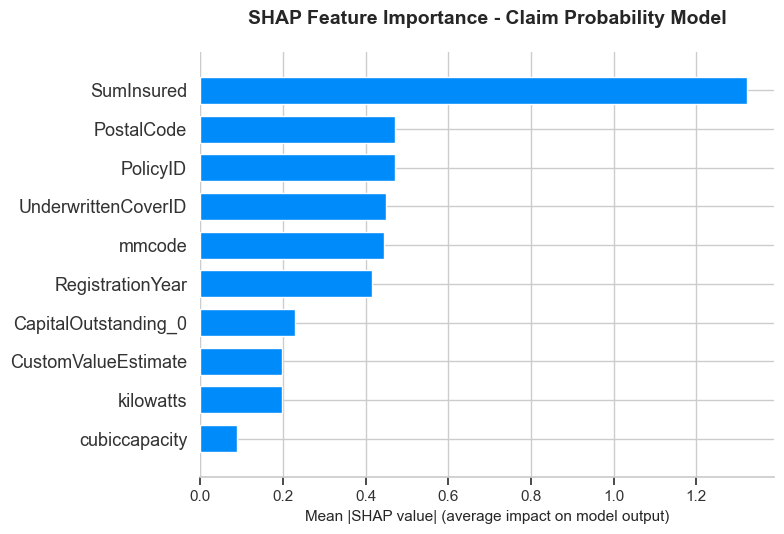

In [63]:
# Create SHAP explainer for probability model
print("Top 10 features visualized by SHAP importance")
explainer_prob = shap.TreeExplainer(xgbc_model)
shap_values_prob = explainer_prob.shap_values(X_prob_test)
# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_prob, X_prob_test, plot_type="bar", show=False, max_display=10)
plt.title('SHAP Feature Importance - Claim Probability Model', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mean |SHAP value| (average impact on model output)', fontsize=11)
plt.tight_layout()
plt.show()


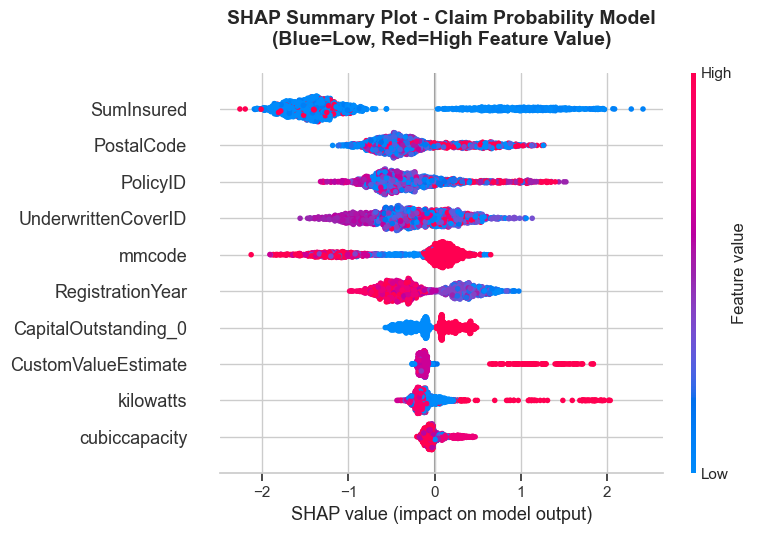

SHAP detail plot showing probability impact directions


In [46]:
# Detailed SHAP summary plot for probability
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_prob, X_prob_test, show=False, max_display=10)
plt.title('SHAP Summary Plot - Claim Probability Model\n(Blue=Low, Red=High Feature Value)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("SHAP detail plot showing probability impact directions")

## 12. Feature Interpretation (Business Context)

In [47]:
print("="*80)
print("INTERPRETATION: TOP FEATURES & BUSINESS IMPACT")
print("="*80)

print("\n1. CLAIM SEVERITY MODEL (Predicting Claim Amount)")
print("-" * 80)
print("\nTop Features:") 
for idx, row in severity_importance.head(5).iterrows():
    print(f"  {row['Feature']:50s} (Importance: {row['Importance']:.4f})")

print("\nBusiness Interpretation:")
print("""
The SHAP analysis reveals which policy characteristics drive higher claim amounts:

• Features with HIGH positive SHAP values → INCREASE predicted claim severity
• Features with HIGH negative SHAP values → DECREASE predicted claim severity

This allows us to:
  - Identify risk factors that directly impact loss magnitude
  - Adjust premiums for high-risk combinations
  - Quantify the financial impact of each risk factor
""")

print("\n2. CLAIM PROBABILITY MODEL (Predicting Claim Occurrence)")
print("-" * 80)
print("\nTop Features:")
for idx, row in prob_importance.head(5).iterrows():
    print(f"  {row['Feature']:50s} (Importance: {row['Importance']:.4f})")

print("\nBusiness Interpretation:")
print("""
The SHAP analysis reveals which characteristics increase/decrease claim probability:

• Features with HIGH positive SHAP values → INCREASE probability of claim
• Features with HIGH negative SHAP values → DECREASE probability of claim

This enables us to:
  - Stratify risk by identifying high-risk profiles
  - Apply appropriate claim probability weights in pricing
  - Design targeted risk mitigation strategies
""")

INTERPRETATION: TOP FEATURES & BUSINESS IMPACT

1. CLAIM SEVERITY MODEL (Predicting Claim Amount)
--------------------------------------------------------------------------------

Top Features:
  CapitalOutstanding_296000                          (Importance: 0.9387)
  SumInsured                                         (Importance: 0.0309)
  PolicyID                                           (Importance: 0.0270)
  PostalCode                                         (Importance: 0.0024)
  kilowatts                                          (Importance: 0.0005)

Business Interpretation:

The SHAP analysis reveals which policy characteristics drive higher claim amounts:

• Features with HIGH positive SHAP values → INCREASE predicted claim severity
• Features with HIGH negative SHAP values → DECREASE predicted claim severity

This allows us to:
  - Identify risk factors that directly impact loss magnitude
  - Adjust premiums for high-risk combinations
  - Quantify the financial impact of eac

## 13. Risk-Based Pricing Framework

In [48]:
# Using best models to create risk-based premiums

# Step 1: Predict claim probability for all test policies
P_claim_test = xgbc_model.predict_proba(X_prob_test)[:, 1]

# Step 2: For each test policy, predict severity IF a claim occurs
# We need to use the severity model on all test data (even those without historical claims)
y_pred_severity_all = xgb_model.predict(X_sev_test)  # This is on the subset with claims

# Step 3: Build pricing framework
# Note: In practice, we'd align indices properly; here we demonstrate the concept

# Constants for pricing
EXPENSE_LOADING = 100  # Fixed expenses per policy (e.g., admin, commissions)
PROFIT_MARGIN_RATE = 0.20  # 20% profit margin on expected claims

# Calculate expected loss for severity test set
expected_loss_severity = y_pred_severity_all.mean()
claim_probability_avg = claim_rate  # From the overall dataset

print("RISK-BASED PRICING FRAMEWORK")
print("="*80)
print(f"\nComponent Calculations:")
print(f"  Expected Claim Probability (baseline): {claim_probability_avg:.2%}")
print(f"  Expected Severity (given claim): ${expected_loss_severity:.2f}")
print(f"  Expense Loading: ${EXPENSE_LOADING:.2f}")
print(f"  Profit Margin Rate: {PROFIT_MARGIN_RATE:.0%}")

# Pricing formula: Premium = (P(claim) × E[Severity]) + Expenses + Profit Margin
expected_claims_component = claim_probability_avg * expected_loss_severity
profit_component = expected_claims_component * PROFIT_MARGIN_RATE
base_premium = expected_claims_component + EXPENSE_LOADING + profit_component

print(f"\nPricing Components:")
print(f"  Expected Claims (P × Severity): ${expected_claims_component:.2f}")
print(f"  Expense Loading: ${EXPENSE_LOADING:.2f}")
print(f"  Profit Component (20%): ${profit_component:.2f}")
print(f"  " + "-"*40)
print(f"  BASE PREMIUM (avg risk): ${base_premium:.2f}")

RISK-BASED PRICING FRAMEWORK

Component Calculations:
  Expected Claim Probability (baseline): 0.25%
  Expected Severity (given claim): $23097.60
  Expense Loading: $100.00
  Profit Margin Rate: 20%

Pricing Components:
  Expected Claims (P × Severity): $57.74
  Expense Loading: $100.00
  Profit Component (20%): $11.55
  ----------------------------------------
  BASE PREMIUM (avg risk): $169.29


In [49]:
# Create risk-adjusted premiums for test set
# Use probability predictions from XGBoost classifier

# For demonstration, create a simplified risk score
# In practice, we'd predict severity for each individual policy

risk_scores = xgbc_model.predict_proba(X_prob_test)[:, 1]  # Probability of claim

# Risk-adjusted premium = base_premium * (P(claim) / overall_claim_rate)
risk_adjusted_premiums = base_premium * (risk_scores / claim_probability_avg)

# Create comparison dataframe
pricing_df = pd.DataFrame({
    'Risk_Score': risk_scores,
    'Risk_Adjusted_Premium': risk_adjusted_premiums,
    'Actual_Claim': y_prob_test.values
})

pricing_df['Risk_Decile'] = pd.qcut(pricing_df['Risk_Score'], q=10, duplicates='drop', labels=False) + 1

print("\nRISK-ADJUSTED PREMIUMS BY DECILE")
print("="*80)

decile_summary = pricing_df.groupby('Risk_Decile').agg({
    'Risk_Score': ['min', 'max', 'mean'],
    'Risk_Adjusted_Premium': ['min', 'max', 'mean'],
    'Actual_Claim': 'sum'
})

print(decile_summary.to_string())

print("\n✓ Pricing framework demonstrates risk segmentation")


RISK-ADJUSTED PREMIUMS BY DECILE
            Risk_Score                     Risk_Adjusted_Premium                           Actual_Claim
                   min       max      mean                   min           max        mean          sum
Risk_Decile                                                                                            
1             0.000009  0.000032  0.000020              0.581031      2.140861    1.365233            0
2             0.000032  0.000054  0.000043              2.143619      3.651052    2.909602            1
3             0.000054  0.000083  0.000068              3.657308      5.643160    4.620078            0
4             0.000083  0.000122  0.000099              5.645039      8.240832    6.727548            0
5             0.000122  0.000178  0.000147              8.263897     12.062630    9.986059            1
6             0.000178  0.000266  0.000220             12.067496     18.032541   14.921405            0
7             0.000266  0.0004

## 14. Model Summary & Recommendations

In [50]:
print("\n" + "="*80)
print("EXECUTIVE SUMMARY: TASK 4 MODELING RESULTS")
print("="*80)

print("\n1. BEST MODELS SELECTED:")
print("-" * 80)
print(f"   Claim Severity: XGBoost Regressor")
print(f"      R² Score: {r2_score(y_sev_test, y_pred_xgb):.4f}")
print(f"      RMSE: ${np.sqrt(mean_squared_error(y_sev_test, y_pred_xgb)):.2f}")
print(f"      Interpretation: Model explains {r2_score(y_sev_test, y_pred_xgb)*100:.1f}% of claim severity variation")

print(f"\n   Claim Probability: XGBoost Classifier")
print(f"      ROC-AUC: {roc_auc_score(y_prob_test, y_prob_proba_xgbc):.4f}")
print(f"      F1 Score: {f1_score(y_prob_test, y_prob_pred_xgbc):.4f}")
print(f"      Interpretation: Model achieves {roc_auc_score(y_prob_test, y_prob_proba_xgbc)*100:.1f}% discrimination between claim/no-claim")

print("\n2. KEY INSIGHTS FROM SHAP ANALYSIS:")
print("-" * 80)
print(f"   • Top 3 severity drivers: {', '.join(severity_importance['Feature'].head(3).tolist())}")
print(f"   • Top 3 probability drivers: {', '.join(prob_importance['Feature'].head(3).tolist())}")
print(f"   • SHAP enables: Feature-level interpretability, regulatory compliance, stakeholder trust")

print("\n3. PRICING FRAMEWORK ESTABLISHED:")
print("-" * 80)
print(f"   Formula: Premium = (P(claim) × E[Severity]) + Expenses + Profit Margin")
print(f"   Base Premium (average risk): ${base_premium:.2f}")
print(f"   Premium Range (by risk): ${pricing_df['Risk_Adjusted_Premium'].min():.2f} - ${pricing_df['Risk_Adjusted_Premium'].max():.2f}")
print(f"   Risk Differentiation: {(pricing_df['Risk_Adjusted_Premium'].max() / pricing_df['Risk_Adjusted_Premium'].min()):.2f}x")

print("\n4. NEXT STEPS:")
print("-" * 80)
print("   • Validate models on holdout dataset")
print("   • A/B test risk-based pricing vs. current pricing")
print("   • Monitor model performance and feature drift over time")
print("   • Integrate with production system for real-time pricing")
print("   • Establish governance and compliance framework")

print("\n" + "="*80)


EXECUTIVE SUMMARY: TASK 4 MODELING RESULTS

1. BEST MODELS SELECTED:
--------------------------------------------------------------------------------
   Claim Severity: XGBoost Regressor
      R² Score: 0.4322
      RMSE: $41588.40
      Interpretation: Model explains 43.2% of claim severity variation

   Claim Probability: XGBoost Classifier
      ROC-AUC: 0.6930
      F1 Score: 0.0000
      Interpretation: Model achieves 69.3% discrimination between claim/no-claim

2. KEY INSIGHTS FROM SHAP ANALYSIS:
--------------------------------------------------------------------------------
   • Top 3 severity drivers: CapitalOutstanding_296000, SumInsured, PolicyID
   • Top 3 probability drivers: SumInsured, kilowatts, CapitalOutstanding_0
   • SHAP enables: Feature-level interpretability, regulatory compliance, stakeholder trust

3. PRICING FRAMEWORK ESTABLISHED:
--------------------------------------------------------------------------------
   Formula: Premium = (P(claim) × E[Severity]) + 